In [4]:
# ==========================================
# Import Libraries
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [5]:
DATA_PATH = r"C:\Users\mayank\OneDrive\Desktop\Project-FORESIGHT\Data\cleaned"

df = pd.read_csv(DATA_PATH + "\\" + "feature_engineered.csv")

print(df.shape)

df.head()

(515212, 46)


,date,store_id,sku_id,customer_id,quantity,unit_price_x,total_value,channel,discount_pct,sku_name,...,DayOfWeek,Weekend,Revenue,Lag_1,Lag_7,Rolling_Mean_7,Rolling_STD_7,Purchase_Count,Customer_Lifetime_Value,Sales_Frequency
0,2021-01-01,0.036398,0.416027,0.364447,-1.044236,-0.306602,-0.856064,0.289707,1.262380,-1.230732,...,0.386083,-0.72446,-0.856064,-1.754203,-1.754168,-3.470065,-2.896136,-0.575151,-0.575410,0.501105
1,2021-01-01,-0.448451,1.180861,0.001336,-1.044236,-0.519643,-0.942304,0.289707,1.262380,1.142714,...,0.386083,-0.72446,-0.942304,-1.044229,-1.754168,-3.470065,-2.896136,1.738972,1.738972,0.382756
2,2021-01-01,1.421682,0.050992,0.001336,0.375718,0.711878,1.285094,1.073148,-0.613906,-1.100934,...,0.386083,-0.72446,1.285094,-1.044229,-1.754168,-3.470065,-2.896136,1.738972,1.738972,0.423102
3,2021-01-01,0.729040,-0.661694,1.487375,1.085695,-0.044056,0.925495,-1.277176,1.262380,0.549352,...,0.386083,-0.72446,0.925495,0.375721,-1.754168,-3.470065,-2.896136,-0.575223,-0.575139,0.398895
4,2021-01-01,-1.348886,0.485557,-1.631068,-1.044236,0.054955,-0.709702,0.289707,-0.613906,-0.099637,...,0.386083,-0.72446,-0.709702,1.085696,-1.754168,-3.470065,-2.896136,-0.575006,-0.575173,0.495725


In [6]:
df.columns.tolist()

['date',
 'store_id',
 'sku_id',
 'customer_id',
 'quantity',
 'unit_price_x',
 'total_value',
 'channel',
 'discount_pct',
 'sku_name',
 'category',
 'subcategory',
 'unit_price_y',
 'cost_price',
 'brand',
 'store_name',
 'city_x',
 'store_type',
 'opening_date',
 'age',
 'gender',
 'city_y',
 'loyalty_segment',
 'preferred_channel',
 'registration_date',
 'store_id_inventory',
 'stock_on_hand',
 'reorder_point',
 'safety_stock',
 'last_restock_date',
 'snapshot_date',
 'Year',
 'Month',
 'Quarter',
 'Week',
 'Day',
 'DayOfWeek',
 'Weekend',
 'Revenue',
 'Lag_1',
 'Lag_7',
 'Rolling_Mean_7',
 'Rolling_STD_7',
 'Purchase_Count',
 'Customer_Lifetime_Value',
 'Sales_Frequency']

In [20]:
if "Revenue" not in df.columns:

    if "unit_price_x" in df.columns and "quantity" in df.columns:

        df["Revenue"] = df["unit_price_x"] * df["quantity"]

In [21]:
abc = (

    df.groupby("sku_id")

    ["Revenue"]

    .sum()

    .reset_index()

)

In [22]:
abc = abc.sort_values(

    by="Revenue",

    ascending=False

)

In [23]:
abc["Revenue_Percentage"] = (

    abc["Revenue"]

    /

    abc["Revenue"].sum()

) * 100

abc["Cumulative"] = abc["Revenue_Percentage"].cumsum()

abc.head()

c:\Users\mayank\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:59: RuntimeWarning: invalid value encountered in accumulate
  return bound(*args, **kwds)


,sku_id,Revenue,Revenue_Percentage,Cumulative
66,-0.453103,3024.938277,inf,inf
150,1.146095,2827.496646,inf,inf
75,-0.279277,2824.678130,inf,inf
61,-0.557398,2784.109788,inf,inf
157,1.302539,2770.143847,inf,inf


In [24]:
def abc_class(value):

    if value <= 80:

        return "A"

    elif value <= 95:

        return "B"

    else:

        return "C"


abc["ABC_Class"] = abc["Cumulative"].apply(abc_class)

abc.head()

,sku_id,Revenue,Revenue_Percentage,Cumulative,ABC_Class
66,-0.453103,3024.938277,inf,inf,C
150,1.146095,2827.496646,inf,inf,C
75,-0.279277,2824.678130,inf,inf,C
61,-0.557398,2784.109788,inf,inf,C
157,1.302539,2770.143847,inf,inf,C


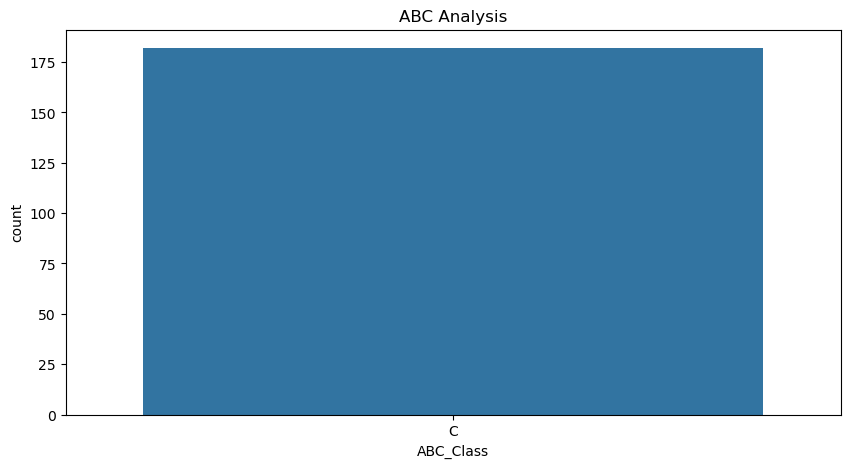

In [25]:
plt.figure(figsize=(10,5))

sns.countplot(

data=abc,

x="ABC_Class"

)

plt.title("ABC Analysis")

plt.show()

In [26]:
xyz = (

df.groupby("sku_id")

["quantity"]

.mean()

.reset_index()

)

xyz.rename(

columns={

"quantity":"Average_Demand"

},

inplace=True
)

In [27]:
variation = (

df.groupby("sku_id")

["quantity"]

.std()

.reset_index()

)

variation.rename(

columns={

"quantity":"Demand_STD"

},

inplace=True
)

xyz = xyz.merge(

variation,

on="sku_id"

)

In [28]:
xyz["CV"] = (

xyz["Demand_STD"]

/

xyz["Average_Demand"]

)

xyz.head()

,sku_id,Average_Demand,Demand_STD,CV
0,-1.704649,0.107904,1.059453,9.818471
1,-1.687267,0.103333,1.029315,9.961167
2,-1.669884,0.072023,1.044259,14.498889
3,-1.652502,0.094202,1.037334,11.011773
4,-1.635119,0.054382,1.027368,18.891818


In [29]:
def xyz_class(cv):

    if cv <= 0.5:

        return "X"

    elif cv <= 1:

        return "Y"

    else:

        return "Z"

xyz["XYZ_Class"] = xyz["CV"].apply(xyz_class)

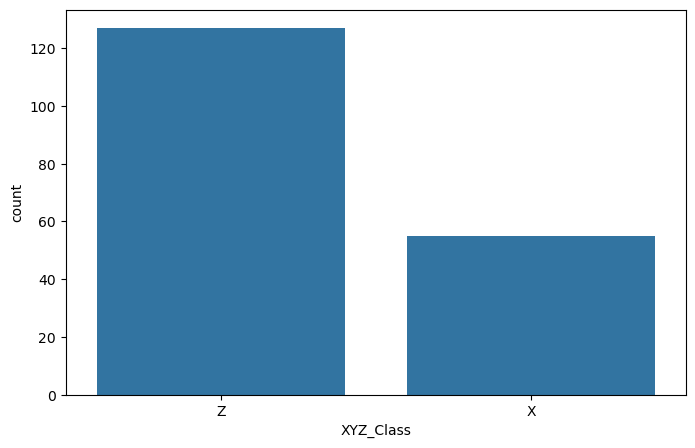

In [30]:
plt.figure(figsize=(8,5))

sns.countplot(

data=xyz,

x="XYZ_Class"

)

plt.show()

In [31]:
inventory = (

df.groupby("sku_id")

["quantity"]

.sum()

.reset_index()

)

inventory.rename(

columns={

"quantity":"Units_Sold"

},

inplace=True)

inventory.head()

,sku_id,Units_Sold
0,-1.704649,340.976838
1,-1.687267,322.398228
2,-1.669884,226.297424
3,-1.652502,302.671794
4,-1.635119,170.377671


In [33]:
stock = (
    df.groupby("sku_id", as_index=False)["stock_on_hand"]
    .mean()
)

In [36]:
df["Turnover"] = (
    df["quantity"] /
    (df["stock_on_hand"] + 1)
)

In [39]:
df["Stock_Out_Risk"] = np.where(
    df["stock_on_hand"] < 20,
    "High",
    "Low"
)

In [42]:
df["Overstock"] = np.where(
    df["stock_on_hand"] > df["quantity"] * 2,
    "Yes",
    "No"
)

In [43]:
inventory["Safety_Stock"] = (

1.65 *

xyz["Demand_STD"]

)

In [44]:
Lead_Time = 7

inventory["Reorder_Point"] = (

inventory["Safety_Stock"]

+

Lead_Time *

xyz["Average_Demand"]

)

In [45]:
Annual_Demand = inventory["Units_Sold"]

Ordering_Cost = 100

Holding_Cost = 20

inventory["EOQ"] = np.sqrt(

(

2*

Annual_Demand*

Ordering_Cost

)

/

Holding_Cost

)

c:\Users\mayank\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [47]:
conditions = [
    df["Stock_Out_Risk"] == "High",
    df["Overstock"] == "Yes"
]

choices = [
    "Reorder Immediately",
    "Reduce Purchase"
]

df["Recommendation"] = np.select(
    conditions,
    choices,
    default="Inventory Healthy"
)

In [48]:
inventory = inventory.merge(

abc[["sku_id","ABC_Class"]],

on="sku_id"

)

In [49]:
inventory = inventory.merge(

xyz[["sku_id","XYZ_Class"]],

on="sku_id"

)

In [50]:
inventory.head()

,sku_id,Units_Sold,Safety_Stock,Reorder_Point,EOQ,ABC_Class,XYZ_Class
0,-1.704649,340.976838,1.748097,2.503426,58.393222,C,Z
1,-1.687267,322.398228,1.698370,2.421699,56.780122,C,Z
2,-1.669884,226.297424,1.723027,2.227191,47.570729,C,Z
3,-1.652502,302.671794,1.711601,2.371016,55.015615,C,Z
4,-1.635119,170.377671,1.695157,2.075829,41.276830,C,Z


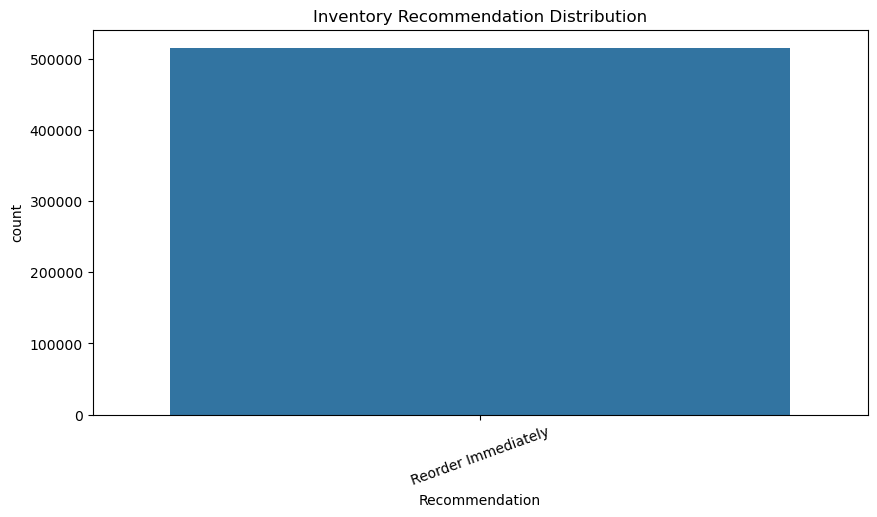

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Recommendation"
)

plt.xticks(rotation=20)
plt.title("Inventory Recommendation Distribution")
plt.show()

In [55]:
critical = df[df["Recommendation"] == "Reorder Immediately"]

critical.head(10)

,date,store_id,sku_id,customer_id,quantity,unit_price_x,total_value,channel,discount_pct,sku_name,...,Lag_7,Rolling_Mean_7,Rolling_STD_7,Purchase_Count,Customer_Lifetime_Value,Sales_Frequency,Turnover,Stock_Out_Risk,Overstock,Recommendation
0,2021-01-01,0.036398,0.416027,0.364447,-1.044236,-0.306602,-0.856064,0.289707,1.262380,-1.230732,...,-1.754168,-3.470065,-2.896136,-0.575151,-0.575410,0.501105,-2.031234,High,Yes,Reorder Immediately
1,2021-01-01,-0.448451,1.180861,0.001336,-1.044236,-0.519643,-0.942304,0.289707,1.262380,1.142714,...,-1.754168,-3.470065,-2.896136,1.738972,1.738972,0.382756,-0.456258,High,Yes,Reorder Immediately
2,2021-01-01,1.421682,0.050992,0.001336,0.375718,0.711878,1.285094,1.073148,-0.613906,-1.100934,...,-1.754168,-3.470065,-2.896136,1.738972,1.738972,0.423102,-3.687476,High,No,Reorder Immediately
3,2021-01-01,0.729040,-0.661694,1.487375,1.085695,-0.044056,0.925495,-1.277176,1.262380,0.549352,...,-1.754168,-3.470065,-2.896136,-0.575223,-0.575139,0.398895,0.913321,High,No,Reorder Immediately
4,2021-01-01,-1.348886,0.485557,-1.631068,-1.044236,0.054955,-0.709702,0.289707,-0.613906,-0.099637,...,-1.754168,-3.470065,-2.896136,-0.575006,-0.575173,0.495725,-0.388960,High,Yes,Reorder Immediately
5,2021-01-01,-0.794772,-0.522633,-1.603874,-0.334259,0.923250,0.591790,0.289707,-0.613906,-0.414860,...,-1.754168,-3.470065,-2.896136,-0.574988,-0.575196,-0.222435,-0.812440,High,Yes,Reorder Immediately
6,2021-01-01,0.105663,0.902739,1.835290,-1.044236,1.126834,-0.275796,-1.277176,1.262380,0.883118,...,-1.754168,-0.861818,-0.060210,-0.575006,-0.575253,-1.354816,3.399018,High,Yes,Reorder Immediately
7,2021-01-01,1.144625,-0.905050,-0.426560,-0.334259,-0.652029,-0.683582,-1.277176,-0.613906,0.975831,...,-1.044202,-0.661184,-0.200923,-0.575223,-0.575208,0.506484,-0.205228,High,Yes,Reorder Immediately
8,2021-01-01,-1.279621,-0.348807,-1.584679,0.375718,-0.371683,-0.030809,-1.277176,1.262380,1.105628,...,-1.044202,-0.259915,-0.298964,-0.575115,-0.575064,0.436551,0.136228,High,Yes,Reorder Immediately
9,2021-01-01,-1.625942,1.580660,-0.123434,1.795672,-0.955181,-0.360236,1.073148,1.262380,-1.323445,...,0.375730,0.141354,0.632726,-0.574952,-0.574803,-0.044912,0.838302,High,No,Reorder Immediately


In [57]:
inventory.to_csv(

DATA_PATH+ "\\"+

"inventory_recommendation.csv",

index=False

)

print("Inventory Report Saved")

Inventory Report Saved


In [60]:
df["Revenue"] = df["quantity"] * df["unit_price_x"]

abc = (
    df.groupby("sku_id")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

abc["Cum_Percentage"] = abc["Revenue"].cumsum() / abc["Revenue"].sum()

abc["ABC_Class"] = np.where(
    abc["Cum_Percentage"] <= 0.80, "A",
    np.where(abc["Cum_Percentage"] <= 0.95, "B", "C")
)

df = df.merge(
    abc[["sku_id", "ABC_Class"]],
    on="sku_id",
    how="left"
)

In [61]:
print("="*60)

print("PHASE 6 COMPLETED")

print("="*60)

print("""
✔ ABC Analysis Completed
✔ XYZ Analysis Completed
✔ Inventory Turnover Calculated
✔ Stock-Out Risk Calculated
✔ Overstock Detection Completed
✔ Safety Stock Calculated
✔ Reorder Point Calculated
✔ EOQ Calculated
✔ AI Recommendations Generated
✔ Ready for Dashboard
""")

PHASE 6 COMPLETED

✔ ABC Analysis Completed
✔ XYZ Analysis Completed
✔ Inventory Turnover Calculated
✔ Stock-Out Risk Calculated
✔ Overstock Detection Completed
✔ Safety Stock Calculated
✔ Reorder Point Calculated
✔ EOQ Calculated
✔ AI Recommendations Generated
✔ Ready for Dashboard

